# ViT-B/16 · RGB-D (DPT) · Masked-autoencoder (MAE) pretraining → frozen linear probe

1. **DPT depth** – Intel DPT-Large depth map for every image → 4-channel RGB-D input (same extraction as the DPT notebooks; cached depth maps are reused).
2. **Masked-autoencoder pretraining (no labels)** – the 4-channel ViT-B/16 sees a random 25% of the 16×16 patches; a small transformer decoder rebuilds the hidden 75% (MSE on the hidden patches). Training split only; the checkpoint with the lowest validation reconstruction loss is kept.
3. **Linear probe** – encoder frozen; one linear layer trained on its 768-d latent vectors (mean of the patch tokens), on the baseline's seed-42 70/15/15 split with the baseline's optimiser, LR schedule, epochs and checkpoint rule.
4. **Latent-space analysis** – PCA, t-SNE, UMAP, Silhouette and K-means (ARI/NMI) on the test-set latent vectors.

Settings follow the plain ViT-B/16 baseline: 224×224, batch 16 × 2 accumulation steps.

In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas tqdm

import os
import time
import math
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
import os
import random
from PIL import Image
from tqdm.notebook import tqdm
from transformers import DPTImageProcessor, DPTForDepthEstimation

# NOTE: dataset path is unchanged from the plain ViT-B/16 baseline -- do not edit.
ORIGINAL_DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"
DEPTH_DATASET_ROOT = "/kaggle/working/tiny-genimage-depth"
DEPTH_BATCH_SIZE = 8

# Same image size / batch size / accumulation as your plain ViT-B/16
# baseline, so the autoencoder sees the data the way the supervised run did.
CONFIG = {
    "seed": 42,
    "image_size": 224,
    "batch_size": 16,
    "accum_steps": 2,
    "num_workers": 2,
    # Stage 1 -- autoencoder pretraining (labels are never used)
    "ae_epochs": 100,
    "ae_learning_rate": 1e-4,
    "ae_early_stop_patience": 10,   # stop once val reconstruction loss hasn't improved for 10 epochs (None = always run all epochs)
    # Stage 2 -- linear probe on the frozen encoder
    "probe_epochs": 100,
    "probe_learning_rate": 1e-4,
    # MAE settings (He et al., 2022): hide 75% of the 16x16 patches, rebuild them
    "mask_ratio": 0.75,
    "decoder_dim": 256,
    "decoder_depth": 4,
    "decoder_heads": 8,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

CLASS_TO_IDX = {"ai": 0, "nature": 1}
IDX_TO_CLASS = {0: "ai", 1: "nature"}

# ==========================================
# 1. OFFLINE DEPTH EXTRACTION (resume-safe)
# ==========================================
# Same DPT step as the 4-channel DPT notebooks. Scans per-file for what's
# actually missing and only loads DPT-Large if there is real work left, so
# depth maps already cached under DEPTH_DATASET_ROOT in this Kaggle session
# (e.g. from one of the DPT notebooks) are reused as-is.
def depth_map_to_uint8(depth_2d):
    d_min, d_max = depth_2d.min(), depth_2d.max()
    if d_max - d_min > 1e-6:
        return ((depth_2d - d_min) / (d_max - d_min) * 255).astype("uint8")
    return np.zeros_like(depth_2d, dtype="uint8")

pending_work = {}
total_pending = 0
for split_name in ["train", "val"]:
    src_dir = os.path.join(ORIGINAL_DATASET_ROOT, split_name)
    dest_dir = os.path.join(DEPTH_DATASET_ROOT, split_name)

    for class_name in os.listdir(src_dir):
        class_src = os.path.join(src_dir, class_name)
        class_dest = os.path.join(dest_dir, class_name)
        if not os.path.isdir(class_src):
            continue
        os.makedirs(class_dest, exist_ok=True)

        pending = [
            n for n in os.listdir(class_src)
            if not os.path.exists(os.path.join(class_dest, os.path.splitext(n)[0] + ".png"))
        ]
        if pending:
            pending_work[(split_name, class_name, class_src, class_dest)] = pending
            total_pending += len(pending)

if total_pending > 0:
    print(f"{total_pending} images missing depth maps. Loading Intel DPT-Large model for extraction...")
    processor = DPTImageProcessor.from_pretrained("Intel/dpt-large")
    dpt_model = DPTForDepthEstimation.from_pretrained("Intel/dpt-large").to(DEVICE)
    dpt_model.eval()

    for (split_name, class_name, class_src, class_dest), pending in pending_work.items():
        for i in tqdm(range(0, len(pending), DEPTH_BATCH_SIZE), desc=f"Extracting Depth - {split_name}/{class_name}"):
            batch_names = pending[i:i + DEPTH_BATCH_SIZE]
            batch_images, valid_names = [], []
            for name in batch_names:
                try:
                    batch_images.append(Image.open(os.path.join(class_src, name)).convert("RGB"))
                    valid_names.append(name)
                except Exception as e:
                    pass

            if not batch_images:
                continue

            inputs = processor(
                images=batch_images,
                size={"height": 384, "width": 384},
                keep_aspect_ratio=False,
                return_tensors="pt"
            ).to(DEVICE)

            with torch.no_grad():
                predicted_depth = dpt_model(**inputs).predicted_depth

            for img, name, depth in zip(batch_images, valid_names, predicted_depth):
                prediction = torch.nn.functional.interpolate(
                    depth.unsqueeze(0).unsqueeze(0),
                    size=img.size[::-1],
                    mode="bicubic",
                    align_corners=False
                )
                formatted = depth_map_to_uint8(prediction.squeeze().cpu().numpy())
                Image.fromarray(formatted).save(os.path.join(class_dest, os.path.splitext(name)[0] + ".png"))

    del dpt_model
    del processor
    torch.cuda.empty_cache()
    print("Extraction complete. DPT cleared from GPU memory.")
else:
    print("Depth maps found for every image. Skipping extraction.")


# ==========================================
# 2. MATCH PAIRS & BUILD 4-CHANNEL DATALOADER
# ==========================================
# Samples are listed train/ai, train/nature, val/ai, val/nature with sorted
# filenames -- the same order ImageFolder + ConcatDataset gave the baseline --
# so the seed-42 70/15/15 split puts the same images in train/val/test.
all_samples = []
for split in ["train", "val"]:
    for class_name, label in CLASS_TO_IDX.items():
        src_class_dir = os.path.join(ORIGINAL_DATASET_ROOT, split, class_name)
        depth_class_dir = os.path.join(DEPTH_DATASET_ROOT, split, class_name)

        for fname in sorted(os.listdir(src_class_dir)):
            rgb_path = os.path.join(src_class_dir, fname)
            depth_path = os.path.join(depth_class_dir, os.path.splitext(fname)[0] + ".png")
            if os.path.exists(depth_path):
                all_samples.append((rgb_path, depth_path, label))

# Fail loudly instead of silently training on a shrunken dataset if any
# depth maps are still missing.
EXPECTED_TOTAL = sum(
    len(os.listdir(os.path.join(ORIGINAL_DATASET_ROOT, split, class_name)))
    for split in ["train", "val"] for class_name in CLASS_TO_IDX
)
assert len(all_samples) == EXPECTED_TOTAL, (
    f"Matched {len(all_samples)} RGB-D pairs but expected {EXPECTED_TOTAL}. "
    "Some depth maps are missing -- rerun the extraction cell before continuing."
)

class RGBDDataset(Dataset):
    def __init__(self, sample_list, is_train=True, img_size=224):
        self.samples = sample_list
        self.is_train = is_train
        self.img_size = img_size
        self.rgb_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.depth_norm = transforms.Normalize(mean=[0.5], std=[0.5])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, depth_path, label = self.samples[idx]
        rgb_img = Image.open(rgb_path).convert("RGB").resize((self.img_size, self.img_size), Image.BILINEAR)
        depth_img = Image.open(depth_path).convert("L").resize((self.img_size, self.img_size), Image.BILINEAR)

        if self.is_train and random.random() < 0.5:
            rgb_img = rgb_img.transpose(Image.FLIP_LEFT_RIGHT)
            depth_img = depth_img.transpose(Image.FLIP_LEFT_RIGHT)

        rgb_t = self.rgb_norm(transforms.functional.to_tensor(rgb_img))
        depth_t = self.depth_norm(transforms.functional.to_tensor(depth_img))
        return torch.cat([rgb_t, depth_t], dim=0), label

total_len = len(all_samples)
train_subset, val_subset, test_subset = random_split(
    all_samples,
    [int(0.7 * total_len), int(0.15 * total_len), total_len - int(0.7 * total_len) - int(0.15 * total_len)],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

train_dataset = RGBDDataset(list(train_subset), is_train=True, img_size=CONFIG["image_size"])
val_dataset = RGBDDataset(list(val_subset), is_train=False, img_size=CONFIG["image_size"])
test_dataset = RGBDDataset(list(test_subset), is_train=False, img_size=CONFIG["image_size"])

print(f"Total matched RGB-D pairs: {total_len}")
print(f"Train pairs: {len(train_dataset)} | Val pairs: {len(val_dataset)} | Test pairs: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

5000 images missing depth maps. Loading Intel DPT-Large model for extraction...


preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

...

Extracting Depth - train/nature:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting Depth - train/ai:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting Depth - val/nature:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting Depth - val/ai:   0%|          | 0/63 [00:00<?, ?it/s]

Extraction complete. DPT cleared from GPU memory.
Total matched RGB-D pairs: 5000
Train pairs: 3500 | Val pairs: 750 | Test pairs: 750


In [3]:
# ==========================================
# MASKED AUTOENCODER (MAE): 4-channel ViT-B/16 encoder + small transformer decoder
# ==========================================
def build_4channel_vit_b16():
    vit = models.vit_b_16(weights=None)

    # Same patch-embedding swap as the DPT notebook: conv_proj (768 filters,
    # 16x16, stride 16) widened from 3 to 4 input channels for RGB + Depth.
    old_conv = vit.conv_proj
    vit.conv_proj = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None
    )
    # torchvision's own patch-embedding init, re-applied to the 4-channel version
    fan_in = vit.conv_proj.in_channels * vit.conv_proj.kernel_size[0] * vit.conv_proj.kernel_size[1]
    nn.init.trunc_normal_(vit.conv_proj.weight, std=math.sqrt(1 / fan_in))
    if vit.conv_proj.bias is not None:
        nn.init.zeros_(vit.conv_proj.bias)

    vit.heads = nn.Identity()   # no classifier head during pretraining
    return vit


class MAEViT(nn.Module):
    """Masked Autoencoder (He et al., CVPR 2022) built around torchvision's ViT-B/16.
    Encoder = the 4-channel ViT, run only on a random 25% of the 196 patches.
    Decoder = small transformer that predicts the RGB-D pixels of the hidden 75%.
    Loss = MSE on the hidden patches only."""
    def __init__(self, vit, mask_ratio=0.75, decoder_dim=256, decoder_depth=4, decoder_heads=8, in_chans=4):
        super().__init__()
        self.vit = vit
        self.mask_ratio = mask_ratio
        self.patch_size = vit.patch_size
        self.in_chans = in_chans
        self.patch_dim = vit.patch_size ** 2 * in_chans
        num_patches = (vit.image_size // vit.patch_size) ** 2

        self.decoder_embed = nn.Linear(vit.hidden_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_dim))
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=decoder_heads, dim_feedforward=4 * decoder_dim,
            dropout=0.0, activation="gelu", batch_first=True, norm_first=True
        )
        self.decoder_blocks = nn.TransformerEncoder(decoder_layer, num_layers=decoder_depth,
                                                    enable_nested_tensor=False)
        self.decoder_norm = nn.LayerNorm(decoder_dim)
        self.decoder_pred = nn.Linear(decoder_dim, self.patch_dim)
        nn.init.normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def patchify(self, imgs):
        # (N, C, H, W) -> (N, num_patches, p*p*C), same patch order as conv_proj
        p = self.patch_size
        n, c, h, w = imgs.shape
        x = imgs.reshape(n, c, h // p, p, w // p, p)
        x = torch.einsum("nchpwq->nhwpqc", x)
        return x.reshape(n, (h // p) * (w // p), p * p * c)

    def unpatchify(self, x):
        # (N, num_patches, p*p*C) -> (N, C, H, W)
        p, c = self.patch_size, self.in_chans
        n, num_patches, _ = x.shape
        g = int(round(num_patches ** 0.5))
        x = x.reshape(n, g, g, p, p, c)
        x = torch.einsum("nhwpqc->nchpwq", x)
        return x.reshape(n, c, g * p, g * p)

    def random_masking(self, x, generator=None):
        # Per-image random shuffle; keep the first (1 - mask_ratio) of the patches
        n, num_patches, d = x.shape
        len_keep = int(num_patches * (1 - self.mask_ratio))
        noise = torch.rand(n, num_patches, device=x.device, generator=generator)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_visible = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, d))
        mask = torch.ones(n, num_patches, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)          # 1 = hidden, 0 = visible
        return x_visible, mask, ids_restore

    def forward_encoder(self, imgs, generator=None):
        vit = self.vit
        x = vit._process_input(imgs)                        # (N, 196, 768) patch tokens
        x = x + vit.encoder.pos_embedding[:, 1:, :]         # add position info before masking
        x, mask, ids_restore = self.random_masking(x, generator)
        cls_token = vit.class_token + vit.encoder.pos_embedding[:, :1, :]
        x = torch.cat([cls_token.expand(x.shape[0], -1, -1), x], dim=1)
        x = vit.encoder.ln(vit.encoder.layers(vit.encoder.dropout(x)))
        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        n, n_visible, d = x.shape
        mask_tokens = self.mask_token.expand(n, ids_restore.shape[1] + 1 - n_visible, -1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens.to(x.dtype)], dim=1)
        x_ = torch.gather(x_, 1, ids_restore.unsqueeze(-1).expand(-1, -1, d))   # un-shuffle
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        x = self.decoder_norm(self.decoder_blocks(x))
        return self.decoder_pred(x[:, 1:, :])               # (N, 196, 16*16*4)

    def forward(self, imgs, generator=None):
        latent, mask, ids_restore = self.forward_encoder(imgs, generator)
        pred = self.forward_decoder(latent, ids_restore)
        target = self.patchify(imgs)
        loss = ((pred.float() - target) ** 2).mean(dim=-1)  # per-patch MSE
        loss = (loss * mask).sum() / mask.sum()             # hidden patches only
        return loss, pred, mask

    def embed(self, imgs):
        # Latent vector for the probe / latent analysis: the full image (no
        # masking), mean of the 196 patch tokens after the final LayerNorm (768-d)
        vit = self.vit
        x = vit._process_input(imgs)
        x = torch.cat([vit.class_token.expand(x.shape[0], -1, -1), x], dim=1)
        x = vit.encoder(x)                                  # adds the position embedding itself
        return x[:, 1:, :].mean(dim=1)


# Re-seed right before building so the weight init doesn't depend on whether
# the DPT extraction ran in the cell above.
set_seed(CONFIG["seed"])
ae_model = MAEViT(
    build_4channel_vit_b16(),
    mask_ratio=CONFIG["mask_ratio"],
    decoder_dim=CONFIG["decoder_dim"],
    decoder_depth=CONFIG["decoder_depth"],
    decoder_heads=CONFIG["decoder_heads"],
).to(DEVICE)

n_enc = sum(p.numel() for p in ae_model.vit.parameters())
n_dec = sum(p.numel() for p in ae_model.parameters()) - n_enc
print(f"4-Channel ViT-B/16 MAE initialized on {DEVICE}.")
print(f"Encoder parameters: {n_enc:,} | Decoder parameters: {n_dec:,}")

# Quick shape check on one real batch before the long run, so a mismatch
# shows up here in seconds instead of hours into training.
ae_model.eval()
with torch.no_grad():
    check_images, _ = next(iter(val_loader))
    check_images = check_images[:2].to(DEVICE)
    check_loss, check_out = ae_model(check_images)[:2]
    check_z = ae_model.embed(check_images)
print(f"Input {tuple(check_images.shape)} -> decoder output {tuple(check_out.shape)} | "
      f"latent vector {tuple(check_z.shape)} | initial loss {check_loss.item():.4f}")

4-Channel ViT-B/16 MAE initialized on cuda.
Encoder parameters: 85,995,264 | Decoder parameters: 3,670,272
Input (2, 4, 224, 224) -> decoder output (2, 196, 1024) | latent vector (2, 768) | initial loss 1.2518


In [4]:
# ==========================================
# STAGE 1 -- AUTOENCODER PRETRAINING (no labels)
# ==========================================
scaler = torch.amp.GradScaler('cuda')

def run_ae_epoch(model, loader, optimizer=None, accum_steps=1):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    # Validation reuses the same random masks every epoch (only matters for
    # the MAE), so val losses are comparable from one epoch to the next.
    generator = None
    if not is_training:
        generator = torch.Generator(device=DEVICE)
        generator.manual_seed(CONFIG["seed"])

    total_loss, n_seen = 0.0, 0
    if is_training:
        optimizer.zero_grad()

    torch.set_grad_enabled(is_training)
    for step, (images, _) in enumerate(loader):        # labels are ignored in this stage
        images = images.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            raw_loss = model(images, generator=generator)[0]
            loss = raw_loss / accum_steps if is_training else raw_loss

        if is_training:
            scaler.scale(loss).backward()
            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        total_loss += raw_loss.item() * images.size(0)
        n_seen += images.size(0)

    torch.set_grad_enabled(True)
    return total_loss / n_seen

ae_optimizer = optim.Adam(ae_model.parameters(), lr=CONFIG["ae_learning_rate"])
# Same schedule as the baselines: halve the LR after 1 epoch without val improvement.
ae_scheduler = optim.lr_scheduler.ReduceLROnPlateau(ae_optimizer, mode="min", factor=0.5, patience=1)

AE_CHECKPOINT_PATH = "/kaggle/working/mae_rgbd_vit_b16_best_checkpoint.pth"
best_ae_val_loss = float("inf")
epochs_since_best = 0
history_ae_train_loss, history_ae_val_loss = [], []

for epoch in range(1, CONFIG["ae_epochs"] + 1):
    start = time.time()
    train_loss = run_ae_epoch(ae_model, train_loader, ae_optimizer, accum_steps=CONFIG["accum_steps"])
    val_loss = run_ae_epoch(ae_model, val_loader, optimizer=None)
    ae_scheduler.step(val_loss)

    history_ae_train_loss.append(train_loss)
    history_ae_val_loss.append(val_loss)

    # No labels in this stage, so the checkpoint is simply the lowest val
    # reconstruction loss.
    saved = val_loss < best_ae_val_loss
    if saved:
        best_ae_val_loss = val_loss
        epochs_since_best = 0
        torch.save(ae_model.state_dict(), AE_CHECKPOINT_PATH)
    else:
        epochs_since_best += 1

    elapsed = time.time() - start
    chkpt_msg = " [*Saved Best Checkpoint]" if saved else ""
    print(f"AE Epoch {epoch:03d}/{CONFIG['ae_epochs']} "
          f"| train_recon={train_loss:.4f} | val_recon={val_loss:.4f} "
          f"| lr={ae_optimizer.param_groups[0]['lr']:.1e} | {elapsed:.1f}s{chkpt_msg}")

    if CONFIG["ae_early_stop_patience"] is not None and epochs_since_best >= CONFIG["ae_early_stop_patience"]:
        print(f"\nEarly stop: val reconstruction loss hasn't improved for {epochs_since_best} epochs.")
        break

ae_model.load_state_dict(torch.load(AE_CHECKPOINT_PATH, map_location=DEVICE))
print(f"\nLoaded best autoencoder checkpoint (val_recon={best_ae_val_loss:.4f}).")

AE Epoch 001/100 | train_recon=1.1021 | val_recon=1.0216 | lr=1.0e-04 | 52.1s [*Saved Best Checkpoint]
AE Epoch 002/100 | train_recon=0.9480 | val_recon=0.9118 | lr=1.0e-04 | 43.2s [*Saved Best Checkpoint]
AE Epoch 003/100 | train_recon=0.9108 | val_recon=0.9003 | lr=1.0e-04 | 43.6s [*Saved Best Checkpoint]
AE Epoch 004/100 | train_recon=0.9001 | val_recon=0.8881 | lr=1.0e-04 | 43.9s [*Saved Best Checkpoint]
AE Epoch 005/100 | train_recon=0.8889 | val_recon=0.8774 | lr=1.0e-04 | 44.1s [*Saved Best Checkpoint]
AE Epoch 006/100 | train_recon=0.8854 | val_recon=0.8725 | lr=1.0e-04 | 44.4s [*Saved Best Checkpoint]
AE Epoch 007/100 | train_recon=0.8796 | val_recon=0.8741 | lr=1.0e-04 | 43.2s
AE Epoch 008/100 | train_recon=0.8714 | val_recon=0.8611 | lr=1.0e-04 | 43.5s [*Saved Best Checkpoint]
AE Epoch 009/100 | train_recon=0.8666 | val_recon=0.8706 | lr=1.0e-04 | 43.1s
AE Epoch 010/100 | train_recon=0.8668 | val_recon=0.8681 | lr=5.0e-05 | 42.9s
AE Epoch 011/100 | train_recon=0.8512 | val_r

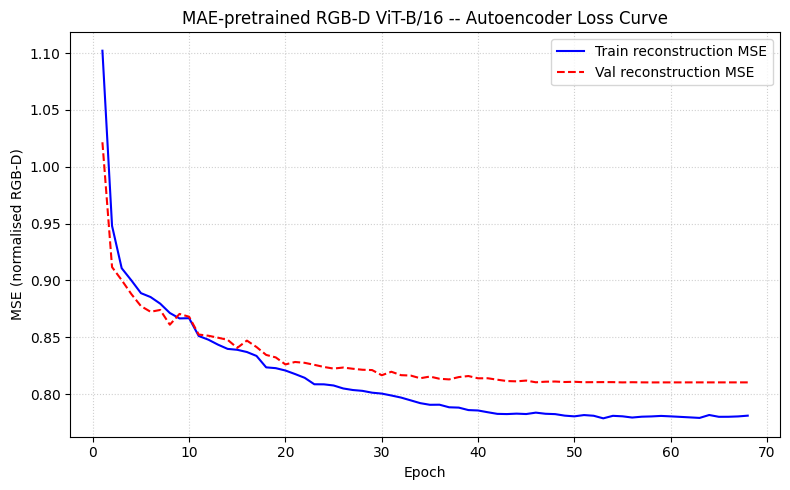

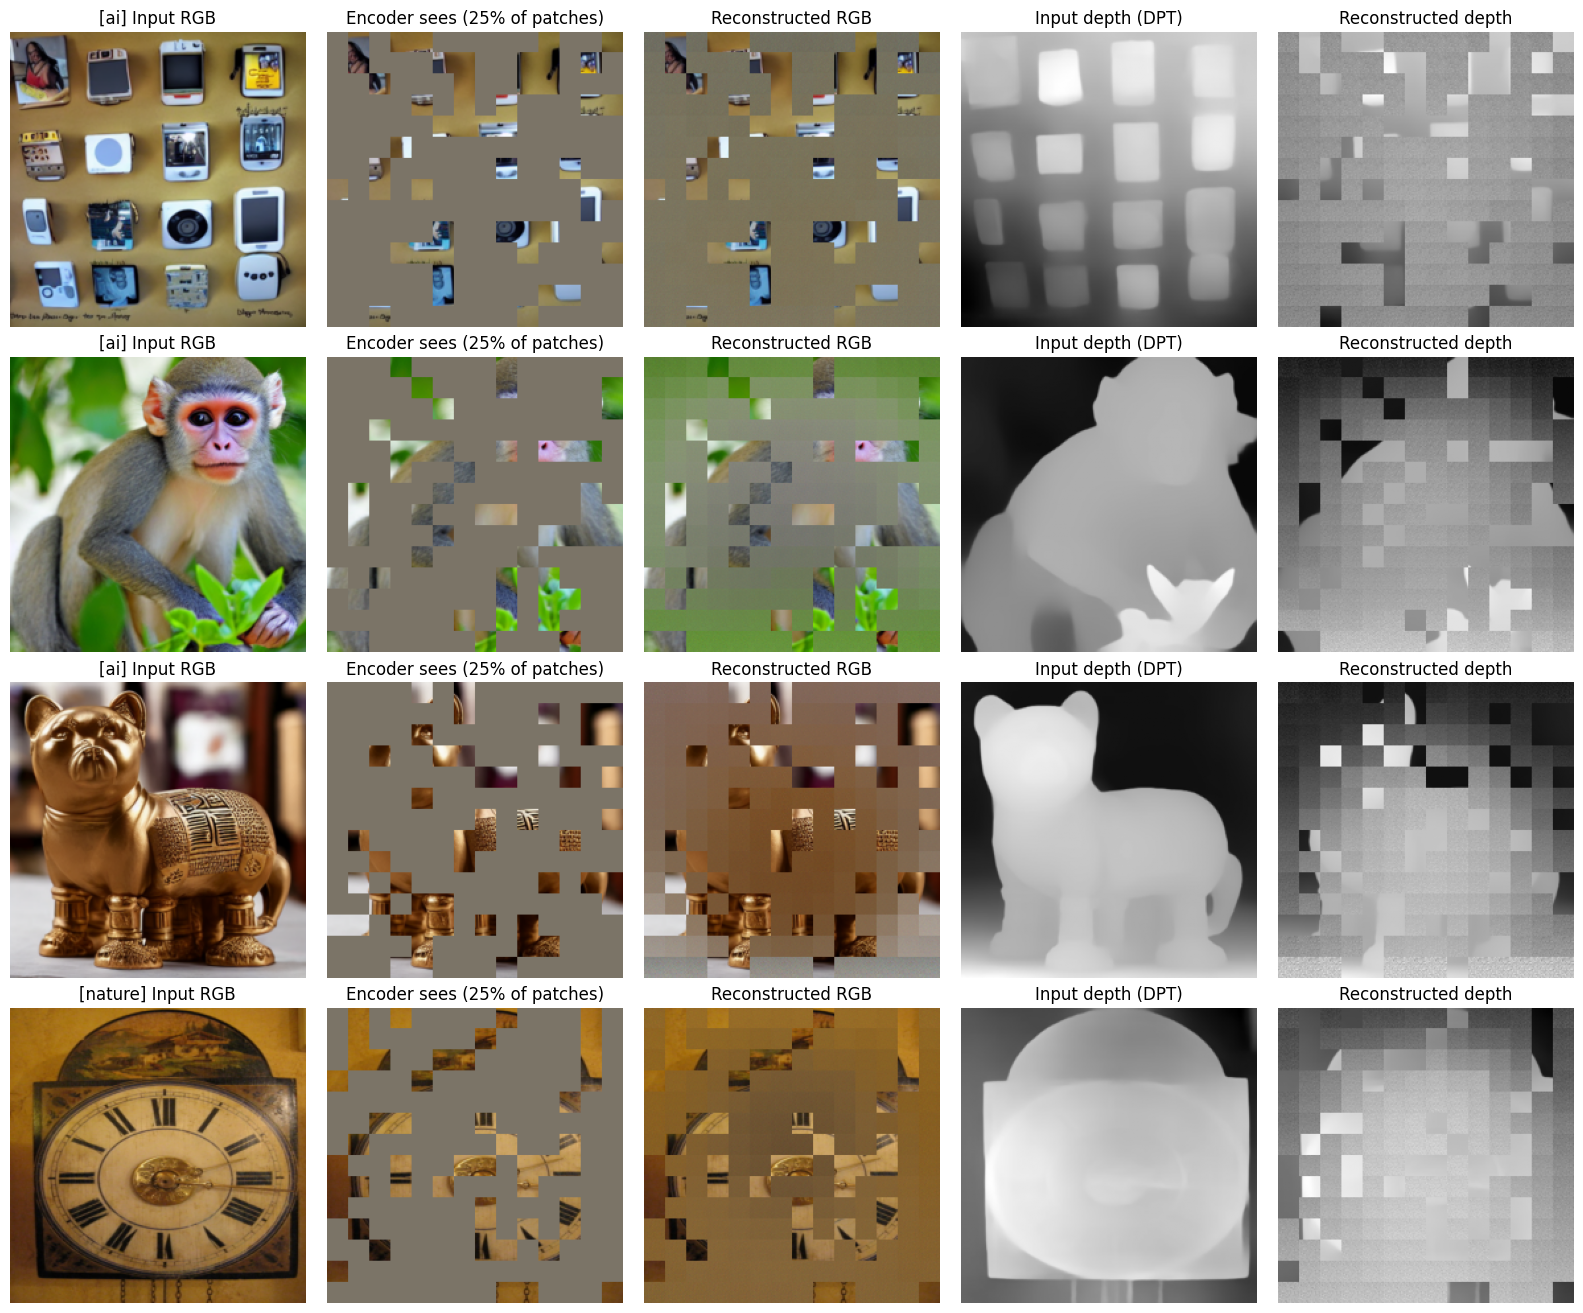

In [5]:
# ==========================================
# AUTOENCODER LOSS CURVE + SAMPLE RECONSTRUCTIONS
# ==========================================
epochs_run = range(1, len(history_ae_train_loss) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_run, history_ae_train_loss, label="Train reconstruction MSE", color="blue")
plt.plot(epochs_run, history_ae_val_loss, label="Val reconstruction MSE", color="red", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE (normalised RGB-D)")
plt.title("MAE-pretrained RGB-D ViT-B/16 -- Autoencoder Loss Curve")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_ae_loss_curve.png"), dpi=150)
plt.show()

RGB_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
RGB_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def to_rgb(t):
    return (t.detach().float().cpu() * RGB_STD + RGB_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

def to_depth(t):
    return (t.detach().float().cpu() * 0.5 + 0.5).clamp(0, 1).numpy()

ae_model.eval()
vis_images, vis_labels = next(iter(test_loader))
vis_images, vis_labels = vis_images[:4].to(DEVICE), vis_labels[:4]
vis_generator = torch.Generator(device=DEVICE)
vis_generator.manual_seed(CONFIG["seed"])
with torch.no_grad():
    _, vis_pred, vis_mask = ae_model(vis_images, generator=vis_generator)
    vis_pred = ae_model.unpatchify(vis_pred.float())
    # 1 where a patch was hidden from the encoder, 0 where it was visible
    mask_map = ae_model.unpatchify(vis_mask.unsqueeze(-1).expand(-1, -1, ae_model.patch_dim))
    vis_masked = vis_images * (1 - mask_map)
    # MAE-paper style: visible patches from the input + predicted patches where hidden
    vis_paste = vis_images * (1 - mask_map) + vis_pred * mask_map

col_titles = ["Input RGB", f"Encoder sees ({round((1 - CONFIG['mask_ratio']) * 100)}% of patches)",
              "Reconstructed RGB", "Input depth (DPT)", "Reconstructed depth"]
fig, axes = plt.subplots(len(vis_images), 5, figsize=(16, 3.3 * len(vis_images)))
for i in range(len(vis_images)):
    panels = [to_rgb(vis_images[i, :3]), to_rgb(vis_masked[i, :3]), to_rgb(vis_paste[i, :3]),
              to_depth(vis_images[i, 3]), to_depth(vis_paste[i, 3])]
    for j, panel in enumerate(panels):
        axes[i, j].imshow(panel, cmap="gray", vmin=0, vmax=1)
        axes[i, j].set_title(f"[{IDX_TO_CLASS[int(vis_labels[i])]}] {col_titles[j]}" if j == 0 else col_titles[j])
        axes[i, j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_reconstructions.png"), dpi=150)
plt.show()

Latent vectors: 768-d | train 3500 | val 750 | test 750
Probe Epoch 001/100 | train_loss=0.6794 train_acc=0.5749 | val_loss=0.6136 val_acc=0.6893 [*Saved Best Checkpoint]
Probe Epoch 002/100 | train_loss=0.5849 train_acc=0.7120 | val_loss=0.5614 val_acc=0.7360 [*Saved Best Checkpoint]
Probe Epoch 003/100 | train_loss=0.5377 train_acc=0.7489 | val_loss=0.5291 val_acc=0.7453 [*Saved Best Checkpoint]
Probe Epoch 004/100 | train_loss=0.5093 train_acc=0.7697 | val_loss=0.5096 val_acc=0.7493 [*Saved Best Checkpoint]
Probe Epoch 005/100 | train_loss=0.4902 train_acc=0.7811 | val_loss=0.4963 val_acc=0.7560 [*Saved Best Checkpoint]
Probe Epoch 006/100 | train_loss=0.4754 train_acc=0.7923 | val_loss=0.4859 val_acc=0.7600 [*Saved Best Checkpoint]
Probe Epoch 007/100 | train_loss=0.4639 train_acc=0.7943 | val_loss=0.4772 val_acc=0.7680 [*Saved Best Checkpoint]
Probe Epoch 008/100 | train_loss=0.4549 train_acc=0.7986 | val_loss=0.4712 val_acc=0.7707 [*Saved Best Checkpoint]
Probe Epoch 009/100 | tr

,dataset,model,num_epochs,ae_pretrain_epochs,train_images,test_images,test_accuracy,test_precision,test_recall,test_f1_score,test_auc
0,tiny_genimage_rgbd_wukong,mae_rgbd_vit_b16,100,68,3500,750,0.8213,0.8224,0.8135,0.8179,0.8944


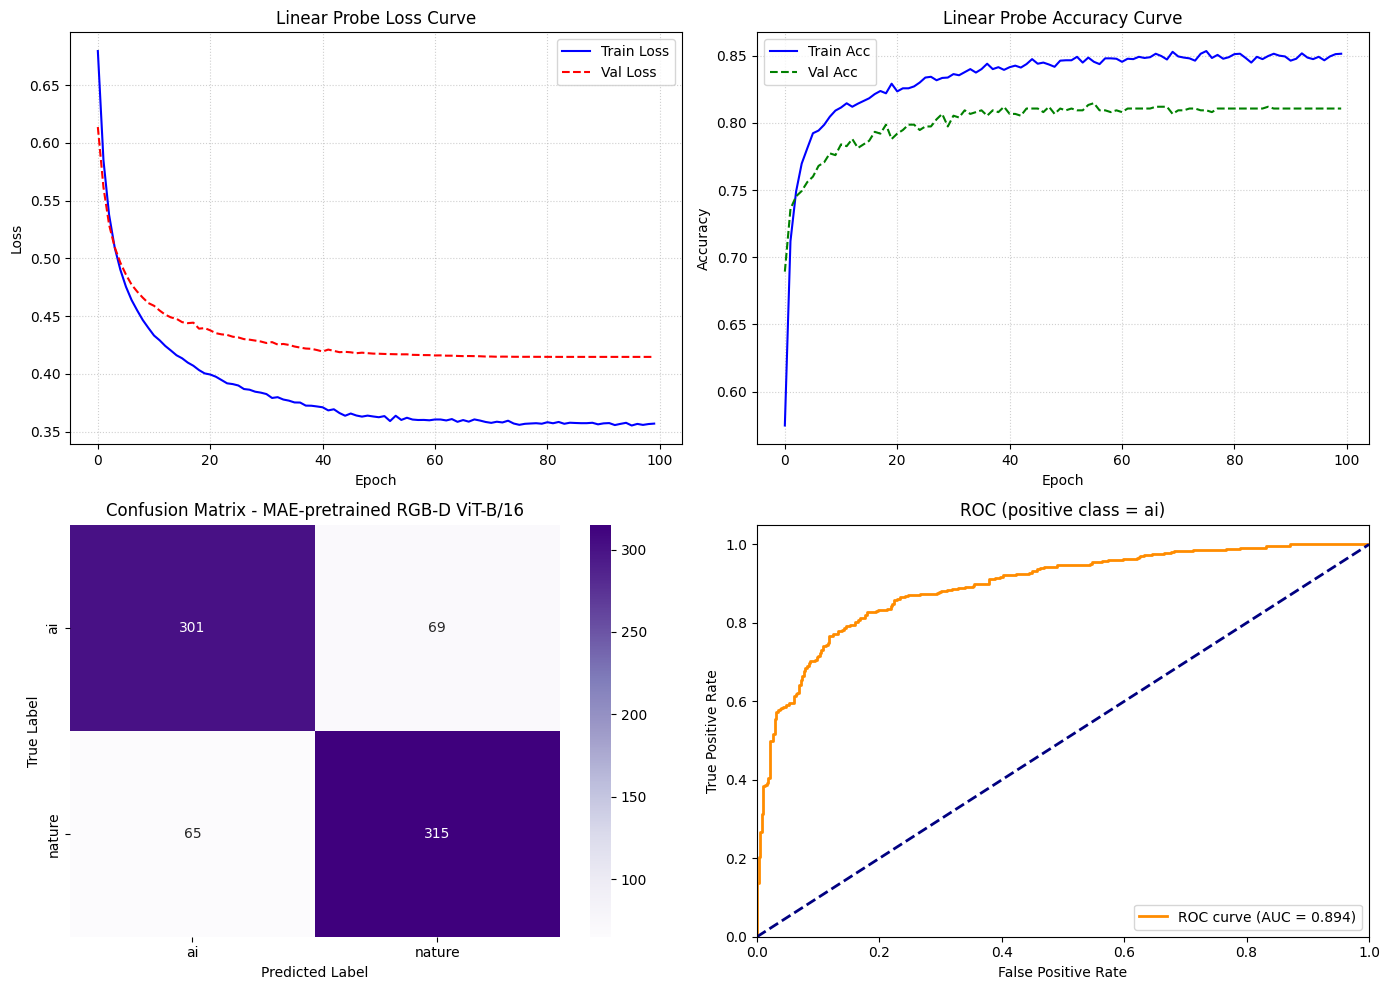

In [6]:
# ==========================================
# STAGE 2 -- FROZEN ENCODER + LINEAR PROBE
# ==========================================
# The autoencoder is frozen from here on. Latent vectors are computed once
# (plus a horizontally flipped copy of the training images, so the probe gets
# the same random-flip augmentation the baselines had); only one linear layer
# is trained on top of them.
for p in ae_model.parameters():
    p.requires_grad = False

@torch.no_grad()
def extract_latents(model, loader, flip=False):
    model.eval()
    feats, labels = [], []
    for images, y in loader:
        images = images.to(DEVICE, non_blocking=True)
        if flip:
            images = torch.flip(images, dims=[3])   # flips RGB and depth together
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z = model.embed(images)
        feats.append(z.float().cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)

train_eval_loader = DataLoader(
    RGBDDataset(train_dataset.samples, is_train=False, img_size=CONFIG["image_size"]),
    batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

X_train, y_train = extract_latents(ae_model, train_eval_loader)
X_train_flip, _ = extract_latents(ae_model, train_eval_loader, flip=True)
X_val, y_val = extract_latents(ae_model, val_loader)
X_test, y_test = extract_latents(ae_model, test_loader)
print(f"Latent vectors: {X_train.shape[1]}-d | train {len(X_train)} | val {len(X_val)} | test {len(X_test)}")

# Standardise with training-set statistics only
feat_mean = X_train.mean(dim=0, keepdim=True)
feat_std = X_train.std(dim=0, keepdim=True)
feat_std[feat_std < 1e-6] = 1.0      # leave constant (dead) dimensions unscaled
X_train, X_train_flip, X_val, X_test = [(t - feat_mean) / feat_std for t in (X_train, X_train_flip, X_val, X_test)]

# ---- Linear probe: same optimiser, LR schedule, epochs and checkpoint rule as the baselines ----
set_seed(CONFIG["seed"])
probe = nn.Linear(X_train.shape[1], 2).to(DEVICE)
probe_criterion = nn.CrossEntropyLoss()
probe_optimizer = optim.Adam(probe.parameters(), lr=CONFIG["probe_learning_rate"])
probe_scheduler = optim.lr_scheduler.ReduceLROnPlateau(probe_optimizer, mode="min", factor=0.5, patience=1)
PROBE_BATCH_SIZE = CONFIG["batch_size"] * CONFIG["accum_steps"]   # the baseline's effective batch size

Xtr, Xtr_flip, ytr = X_train.to(DEVICE), X_train_flip.to(DEVICE), y_train.to(DEVICE)
Xva, yva = X_val.to(DEVICE), y_val.to(DEVICE)
probe_gen = torch.Generator().manual_seed(CONFIG["seed"])

PROBE_CHECKPOINT_PATH = "/kaggle/working/mae_rgbd_vit_b16_probe_best_checkpoint.pth"
best_val_acc = 0.0
best_val_loss = float("inf")
history_probe_train_loss, history_probe_val_loss = [], []
history_probe_train_acc, history_probe_val_acc = [], []

for epoch in range(1, CONFIG["probe_epochs"] + 1):
    probe.train()
    order = torch.randperm(len(ytr), generator=probe_gen).to(DEVICE)
    # Random horizontal flip, as in the baselines: each image uses its flipped latent with p = 0.5
    use_flip = (torch.rand(len(ytr), generator=probe_gen) < 0.5).to(DEVICE)
    X_epoch = torch.where(use_flip[:, None], Xtr_flip, Xtr)

    loss_sum, correct = 0.0, 0
    for i in range(0, len(order), PROBE_BATCH_SIZE):
        idx = order[i:i + PROBE_BATCH_SIZE]
        logits = probe(X_epoch[idx])
        loss = probe_criterion(logits, ytr[idx])
        probe_optimizer.zero_grad()
        loss.backward()
        probe_optimizer.step()
        loss_sum += loss.item() * len(idx)
        correct += (logits.argmax(dim=1) == ytr[idx]).sum().item()
    train_loss, train_acc = loss_sum / len(ytr), correct / len(ytr)

    probe.eval()
    with torch.no_grad():
        val_logits = probe(Xva)
        val_loss = probe_criterion(val_logits, yva).item()
        val_acc = (val_logits.argmax(dim=1) == yva).float().mean().item()
    probe_scheduler.step(val_loss)

    history_probe_train_loss.append(train_loss)
    history_probe_val_loss.append(val_loss)
    history_probe_train_acc.append(train_acc)
    history_probe_val_acc.append(val_acc)

    # Same combined checkpoint rule as the baselines (save on val_acc
    # improving, else on val_loss improving; best_val_loss tracked every epoch)
    saved = False
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(probe.state_dict(), PROBE_CHECKPOINT_PATH)
        saved = True
    elif val_loss < best_val_loss:
        torch.save(probe.state_dict(), PROBE_CHECKPOINT_PATH)
        saved = True

    if val_loss < best_val_loss:
        best_val_loss = val_loss

    chkpt_msg = " [*Saved Best Checkpoint]" if saved else ""
    print(f"Probe Epoch {epoch:03d}/{CONFIG['probe_epochs']} "
          f"| train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}{chkpt_msg}")

probe.load_state_dict(torch.load(PROBE_CHECKPOINT_PATH, map_location=DEVICE))
print("\nLoaded best linear-probe checkpoint for evaluation.")

# ==========================================
# TEST-SET EVALUATION ("ai" = positive class, as in the baselines)
# ==========================================
probe.eval()
with torch.no_grad():
    test_logits = probe(X_test.to(DEVICE)).float().cpu()

pos_lbl = CLASS_TO_IDX.get("ai", 0)
all_labels = y_test.numpy()
all_preds = test_logits.argmax(dim=1).numpy()
all_probs = torch.softmax(test_logits, dim=1)[:, pos_lbl].numpy()

print("===== Classification Report (Test Set - MAE-pretrained RGB-D ViT-B/16, linear probe) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=pos_lbl)
roc_auc = auc(fpr, tpr)

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_lbl
)

results_row = {
    "dataset": "tiny_genimage_rgbd_wukong",
    "model": "mae_rgbd_vit_b16",
    "num_epochs": len(history_probe_train_loss),
    "ae_pretrain_epochs": len(history_ae_train_loss),
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])
display(results_df)

RESULTS_CSV_PATH = os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_AE_PATH = os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_autoencoder.pth")
FINAL_PROBE_PATH = os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_linear_probe.pth")
shutil.copy(AE_CHECKPOINT_PATH, FINAL_AE_PATH)
shutil.copy(PROBE_CHECKPOINT_PATH, FINAL_PROBE_PATH)

# Standardised latent vectors, saved so the latent-space analysis can be
# redone later without re-running the autoencoder
EMBEDDINGS_PATH = os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_latents.npz")
np.savez_compressed(
    EMBEDDINGS_PATH,
    X_train=X_train.numpy(), y_train=y_train.numpy(),
    X_val=X_val.numpy(), y_val=y_val.numpy(),
    X_test=X_test.numpy(), y_test=y_test.numpy(),
    feat_mean=feat_mean.numpy(), feat_std=feat_std.numpy(),
)

# Probe curves, confusion matrix and ROC
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history_probe_train_loss, label="Train Loss", color="blue")
axes[0, 0].plot(history_probe_val_loss, label="Val Loss", color="red", linestyle="--")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Linear Probe Loss Curve")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

axes[0, 1].plot(history_probe_train_acc, label="Train Acc", color="blue")
axes[0, 1].plot(history_probe_val_acc, label="Val Acc", color="green", linestyle="--")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Linear Probe Accuracy Curve")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]], ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted Label")
axes[1, 0].set_ylabel("True Label")
axes[1, 0].set_title("Confusion Matrix - MAE-pretrained RGB-D ViT-B/16")

axes[1, 1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
axes[1, 1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].set_title("ROC (positive class = ai)")
axes[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_probe_results.png"), dpi=150)
plt.show()

PCA: the first 2 components explain 30.7% of the variance


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,model,space,silhouette_true_labels,silhouette_kmeans_k2,kmeans_ari_vs_true,kmeans_nmi_vs_true
0,mae_rgbd_vit_b16,latent (768-d),0.0112,0.1030,0.0028,0.0032
1,mae_rgbd_vit_b16,PCA 2-D,0.0106,0.3245,0.0018,0.0024
2,mae_rgbd_vit_b16,t-SNE 2-D,0.0223,0.4012,0.0095,0.0077
3,mae_rgbd_vit_b16,UMAP 2-D,0.0114,0.4145,0.0064,0.0056


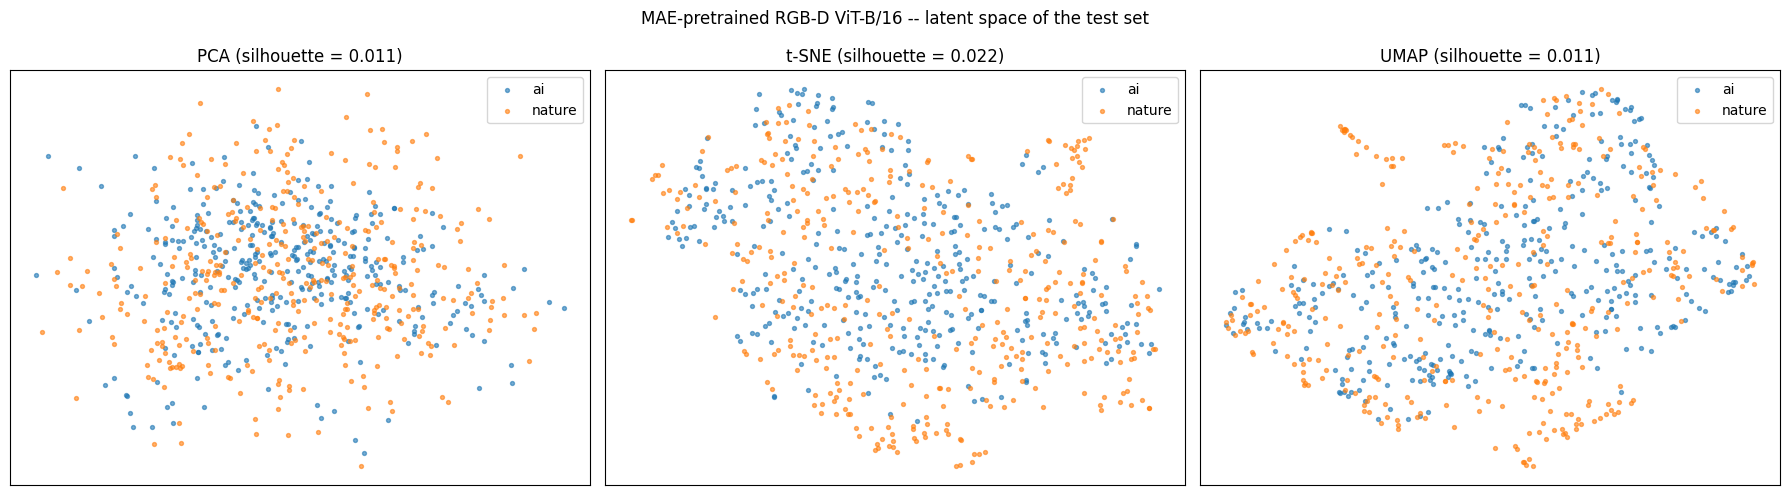


===== Download Links =====


/kaggle/working/results/mae_rgbd_vit_b16_test_results.csv

/kaggle/working/results/mae_rgbd_vit_b16_latent_space_metrics.csv

/kaggle/working/results/mae_rgbd_vit_b16_autoencoder.pth

/kaggle/working/results/mae_rgbd_vit_b16_linear_probe.pth

/kaggle/working/results/mae_rgbd_vit_b16_latents.npz

In [7]:
# ==========================================
# STAGE 3 -- LATENT-SPACE ANALYSIS (frozen encoder, test set)
# ==========================================
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed -- UMAP skipped. Run `!pip install -q umap-learn`, then re-run this cell to add it.")

Z = X_test.numpy()           # standardised latent vectors of the test images
z_labels = y_test.numpy()

pca = PCA(n_components=2, random_state=CONFIG["seed"])
projections = {"PCA": pca.fit_transform(Z)}
print(f"PCA: the first 2 components explain {pca.explained_variance_ratio_.sum() * 100:.1f}% of the variance")
projections["t-SNE"] = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
                            random_state=CONFIG["seed"]).fit_transform(Z)
if HAS_UMAP:
    projections["UMAP"] = umap.UMAP(n_components=2, random_state=CONFIG["seed"]).fit_transform(Z)

def cluster_scores(space_name, X):
    """Silhouette w.r.t. the true ai/nature labels, plus how well an unsupervised
    2-cluster K-means split lines up with those labels (ARI / NMI)."""
    km_labels = KMeans(n_clusters=2, n_init=10, random_state=CONFIG["seed"]).fit_predict(X)
    return {
        "space": space_name,
        "silhouette_true_labels": round(float(silhouette_score(X, z_labels)), 4),
        "silhouette_kmeans_k2": round(float(silhouette_score(X, km_labels)), 4),
        "kmeans_ari_vs_true": round(float(adjusted_rand_score(z_labels, km_labels)), 4),
        "kmeans_nmi_vs_true": round(float(normalized_mutual_info_score(z_labels, km_labels)), 4),
    }

latent_rows = [cluster_scores(f"latent ({Z.shape[1]}-d)", Z)]
latent_rows += [cluster_scores(f"{name} 2-D", P) for name, P in projections.items()]
latent_df = pd.DataFrame(latent_rows)
latent_df.insert(0, "model", "mae_rgbd_vit_b16")
display(latent_df)

LATENT_CSV_PATH = os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_latent_space_metrics.csv")
latent_df.to_csv(LATENT_CSV_PATH, index=False)

fig, axes = plt.subplots(1, len(projections), figsize=(6 * len(projections), 5))
axes = np.atleast_1d(axes)
for ax, (name, P) in zip(axes, projections.items()):
    for cls_idx, cls_name in IDX_TO_CLASS.items():
        pts = P[z_labels == cls_idx]
        ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.6, label=cls_name)
    ax.set_title(f"{name} (silhouette = {silhouette_score(P, z_labels):.3f})")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()
fig.suptitle("MAE-pretrained RGB-D ViT-B/16 -- latent space of the test set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mae_rgbd_vit_b16_latent_space.png"), dpi=150)
plt.show()

print("\n===== Download Links =====")
for path in [RESULTS_CSV_PATH, LATENT_CSV_PATH, FINAL_AE_PATH, FINAL_PROBE_PATH, EMBEDDINGS_PATH]:
    display(FileLink(path))